### This notebook generates a graph with inspiration from the example in the documentation NB from weather-model-graphs

#### Initializations

In [3]:
import sys
sys.path.insert(0, '../')
import data_generation.SimulatorWaveEquation as simu
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.tri as mtri
import weather_model_graphs as wmg 


#### Initializations

In [4]:
R = 1 # Radius
C = 1 # Wave speed
Lmax = 10 # Maximum degree of spherical harmonics
tmax = 10 # Maximum time  
generations = 2 # level of refinement for the grid
x0,y0,z0 = R,R,R # Initial position of the gaussian pulse

In [5]:

# Initial condition: Gaussian pulse centered at (x0, y0, z0)
def f_handle(x, y, z):
    # dot product with center
    dot = x*x0 + y*y0 + z*z0
    
    cos_alpha = np.clip(dot / R**2, -1.0, 1.0)

    alpha = np.arccos(cos_alpha)
     
    return np.exp(-(alpha**2) / (2*0.2**2))

# Initital condition: zero initial velocity
g_handle = lambda x, y, z: 0 * x

#### Simulation

In [8]:
sim = simu.SimulatorWaveEquation(R=1.0, C=C, Lmax=Lmax, tmax=tmax, f_handle=f_handle, g_handle=g_handle, generations=generations)
lat, long, pos, tri = sim.get_lat_long()

#### Plotting with triangular mesh on top

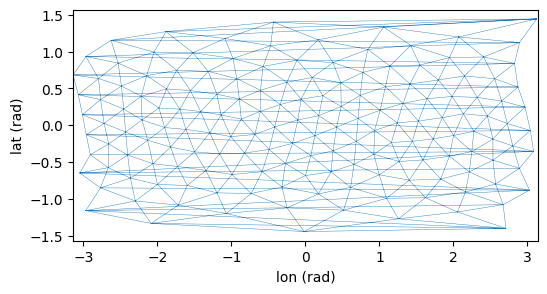

In [12]:
### Tringulation in lat-long space
triang = mtri.Triangulation(long, lat, triangles=tri)
plt.figure(figsize=(6,3))
plt.triplot(triang, linewidth=0.3)
plt.xlim(-np.pi, np.pi)
plt.ylim(-np.pi/2, np.pi/2)
plt.xlabel("lon (rad)")
plt.ylabel("lat (rad)")
plt.savefig("../figures/test/lat_long_triangulation.png")
plt.show()

#### Visualize points without triangles 

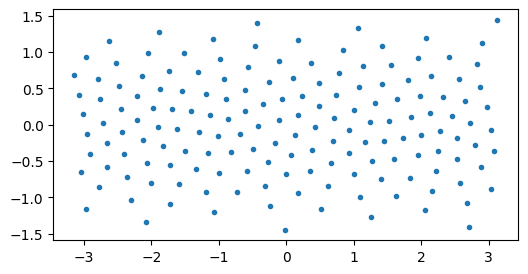

In [15]:
coords = np.stack([long, lat], axis=1)   # (N,2)

fig, ax = plt.subplots(figsize=(6,3))
ax.scatter(coords[:, 0], coords[:, 1], marker=".")


#### Greate graph using weather-model graphs (keisler graph)

2026-02-25 15:48:34.317 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:106 - No `coords_crs` given: Assuming `coords` contains in-projection Cartesian coordinates.


<GeoAxes: >

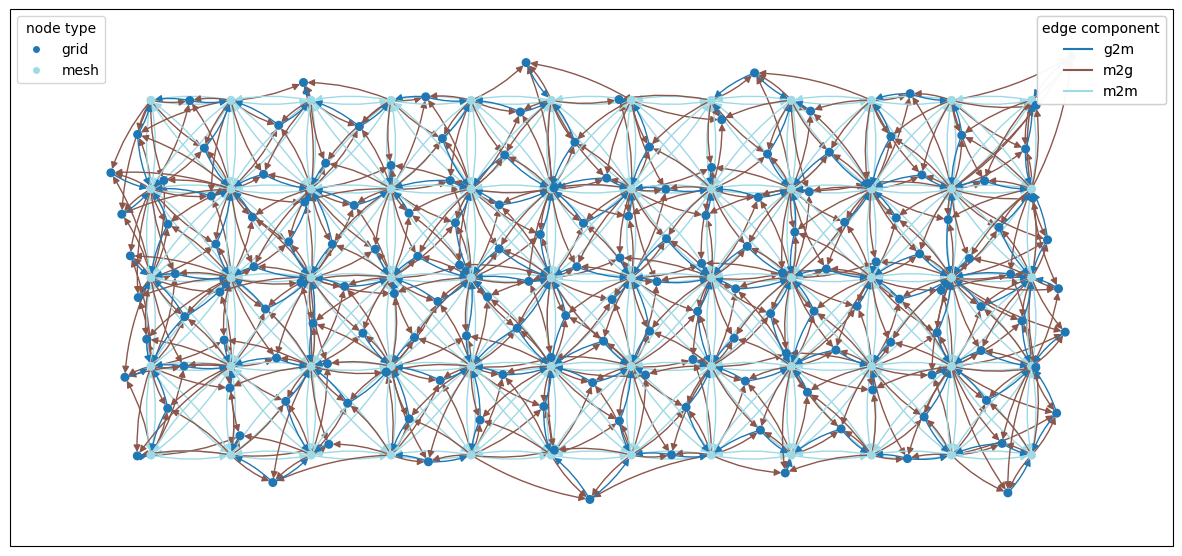

In [ ]:
graph = wmg.create.archetype.create_keisler_graph(coords, mesh_node_distance=0.5)
fig, ax = plt.subplots(figsize=(15, 9), subplot_kw={"projection": ccrs.PlateCarree()})
wmg.visualise.nx_draw_with_pos_and_attr(
    graph, ax=ax, node_size=30, edge_color_attr="component", node_color_attr="type"
)

#### Create splitted graphs

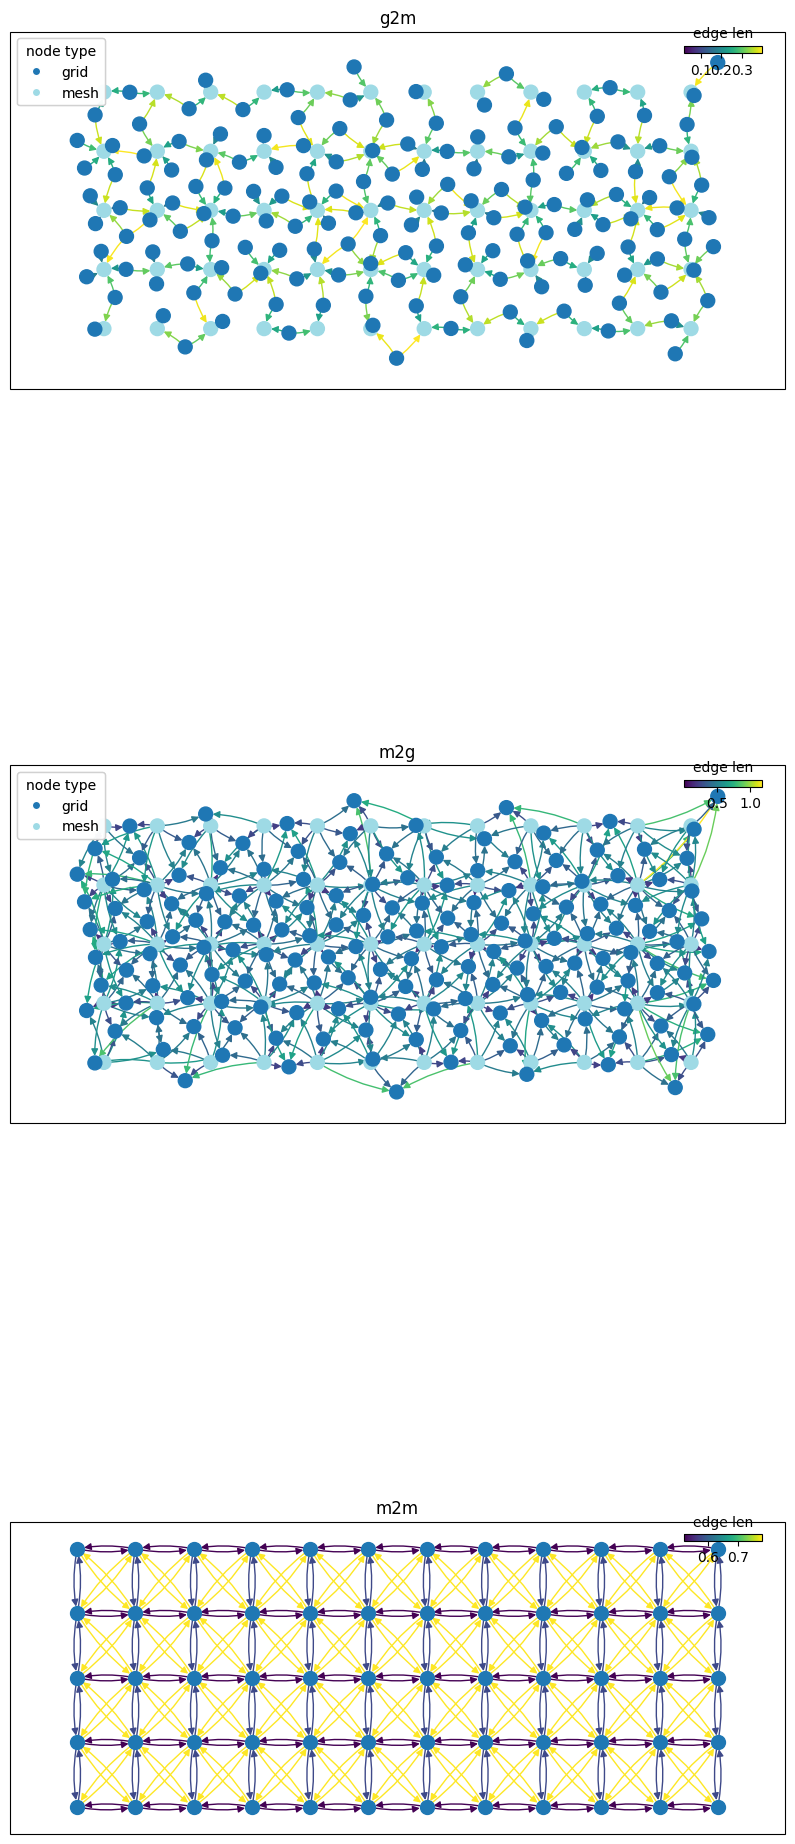

In [17]:
graph_components = wmg.split_graph_by_edge_attribute(graph=graph, attr="component")

n_components = len(graph_components)
fig, axes = plt.subplots(nrows=n_components, ncols=1, figsize=(10, 9 * n_components), subplot_kw={"projection": ccrs.PlateCarree()})

for (name, g), ax in zip(graph_components.items(), axes.flatten()):
    pl_kwargs = {}
    if name == "m2m":
        pl_kwargs = dict(edge_color_attr="len")
    elif name == "g2m" or name == "m2g":
        pl_kwargs = dict(edge_color_attr="len", node_color_attr="type")

    wmg.visualise.nx_draw_with_pos_and_attr(graph=g, ax=ax, **pl_kwargs)
    ax.set_title(name)
    ax.set_aspect(1.0)

plt.savefig("../figures/test/split_graphs.png")
plt.show()